In [ ]:


"""
Mixed-wet Validation using Game Theory Potential Game Approach
Comparing with Blunt et al. (2019) Table 2 data - COMPLETE VISUALIZATION VERSION
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm
import random
import time
from mpl_toolkits.mplot3d import Axes3D


# تنظیمات حرفه‌ای برای مقاله
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'Times New Roman',  # یا 'Times New Roman' برای مقاله
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'png',
    'savefig.bbox': 'tight',
    'lines.linewidth': 1.5,
    'axes.linewidth': 1,
    'grid.alpha': 0.3
})

#plt.switch_backend('TkAgg')
# =============================================================================
# STEP 1: Reference Data from Blunt et al. Table 2 (Mixed-wet case)
# =============================================================================
BLUNT_MIXEDWET_DATA = {
    'phi': 0.231,  # Porosity
    'theta_t_expected': 88.6,  # Thermodynamic angle from Table 2
    'theta_g_mean': 80.8,  # Average geometric angle from Fig 2
    # Data from Table 2 for comparison
    'states': [
        {'f_w': 0.24, 'S_w': 0.320, 'a_wo': 1.57, 'a_ws': 5.39, 'kappa': -4.99, 'theta_g': 79.1},
        {'f_w': 0.50, 'S_w': 0.482, 'a_wo': 1.83, 'a_ws': 7.61, 'kappa': -5.44, 'theta_g': 80.4},
        {'f_w': 0.80, 'S_w': 0.655, 'a_wo': 1.67, 'a_ws': 9.80, 'kappa': -5.05, 'theta_g': 82.3},
        {'f_w': 0.90, 'S_w': 0.700, 'a_wo': 1.65, 'a_ws': 10.5, 'kappa': -2.84, 'theta_g': 81.5}
    ]
}

SIGMA_OW = 0.0515  # N/m (oil-water interfacial tension)

print("=== REFERENCE DATA FROM BLUNT ET AL. (MIXED-WET) ===")
print(f"Porosity: {BLUNT_MIXEDWET_DATA['phi']:.3f}")
print(f"Expected θ_t: {BLUNT_MIXEDWET_DATA['theta_t_expected']:.1f}°")
print(f"Average geometric θ_g: {BLUNT_MIXEDWET_DATA['theta_g_mean']:.1f}°")
print()

# =============================================================================
# STEP 2: Create Mixed-wet Pore Network (keeping your original parameters)
# =============================================================================
def create_mixedwet_pore_network(nx=20, ny=20, nz=20, porosity_target=0.231):
    """Create a 3D pore network for mixed-wet system"""
    N = nx * ny * nz
    is_pore = np.ones((nx, ny, nz), dtype=bool)

    solid_fraction = 1.0 - porosity_target
    num_solid = int(N * solid_fraction)
    all_positions = [(i, j, k) for i in range(nx) for j in range(ny) for k in range(nz)]
    solid_positions = random.sample(all_positions, num_solid)

    for pos in solid_positions:
        is_pore[pos] = False

    pore_radii = np.zeros((nx, ny, nz))
    valid_pores = np.where(is_pore)
    num_valid = len(valid_pores[0])

    # Log-normal distribution of pore radii (in microns)
    radii_log = np.random.normal(np.log(100), 0.5, num_valid)  # Mean ~100 micron
    radii = np.exp(radii_log)
    pore_radii[valid_pores] = radii * 1e-6  # Convert to meters

    pore_surface_areas = 4 * np.pi * pore_radii**2
    pore_volumes = (4/3) * np.pi * pore_radii**3

    return is_pore, pore_radii, pore_surface_areas, pore_volumes

# =============================================================================
# STEP 3: Generate Mixed-wet Contact Angle Distribution (keeping your original)
# =============================================================================
def generate_mixedwet_contact_angles(num_pores, mean_deg=81, std_deg=15):
    """Generate truncated normal distribution for mixed-wet system"""
    mean_rad = np.radians(mean_deg)
    std_rad = np.radians(std_deg)
    a_deg, b_deg = 30, 150  # Truncation bounds in degrees
    a_rad, b_rad = np.radians(a_deg), np.radians(b_deg)

    a_trunc = (a_rad - mean_rad) / std_rad
    b_trunc = (b_rad - mean_rad) / std_rad

    contact_angles_rad = truncnorm.rvs(a_trunc, b_trunc, loc=mean_rad, scale=std_rad, size=num_pores)
    return np.degrees(contact_angles_rad)

# =============================================================================
# STEP 4: Game Theory Implementation (Modified for Complete Visualization)
# =============================================================================
class MixedWetPoreGameTheory:
    def __init__(self, is_pore, pore_radii, pore_surface_areas, contact_angles_deg, lambda_val=1.0):
        self.is_pore = is_pore
        self.pore_radii = pore_radii
        self.pore_surface_areas = pore_surface_areas
        self.contact_angles_deg = contact_angles_deg
        self.lambda_val = lambda_val
        self.sigma_ow = SIGMA_OW

        # Convert to cosθ for energy calculations
        self.cos_theta = np.cos(np.radians(contact_angles_deg))

        self.nx, self.ny, self.nz = is_pore.shape
        self.phases = np.ones_like(is_pore, dtype=int)  # Start with all oil (1)

        # Store valid pore indices for faster access
        valid_pores = np.where(is_pore)
        self.valid_indices = list(zip(valid_pores[0], valid_pores[1], valid_pores[2]))
        self.num_valid = len(self.valid_indices)

        # Pre-compute neighbor relationships
        self._build_neighbor_list()

    def _build_neighbor_list(self):
        """Precompute neighbor lists for all pores"""
        self.neighbors = {}
        directions = [(1,0,0), (-1,0,0), (0,1,0), (0,-1,0), (0,0,1), (0,0,-1)]

        for i, j, k in self.valid_indices:
            neighbor_list = []
            for di, dj, dk in directions:
                ni, nj, nk = i + di, j + dj, k + dk
                if (0 <= ni < self.nx and 0 <= nj < self.ny and 0 <= nk < self.nz and
                    self.is_pore[ni, nj, nk]):
                    neighbor_list.append((ni, nj, nk))
            self.neighbors[(i, j, k)] = neighbor_list

    def get_pore_index(self, i, j, k):
        """Get index in flat arrays for pore at (i,j,k)"""
        valid_pores = np.where(self.is_pore)
        idx = np.where((valid_pores[0] == i) & (valid_pores[1] == j) & (valid_pores[2] == k))[0]
        return idx[0] if len(idx) > 0 else -1

    def calculate_energy_change(self, i, j, k, new_phase):
        """Calculate energy change if pore changes phase"""
        current_phase = self.phases[i, j, k]
        if current_phase == new_phase:
            return 0.0

        # Get index for cosθ
        idx = self.get_pore_index(i, j, k)
        if idx == -1:
            return 0.0

        # Wettability energy change
        delta_energy = self.sigma_ow * self.cos_theta[idx] * self.pore_surface_areas[i, j, k] * (new_phase - current_phase)

        # Interface energy change with neighbors
        for ni, nj, nk in self.neighbors[(i, j, k)]:
            neighbor_phase = self.phases[ni, nj, nk]
            current_interface = abs(current_phase - neighbor_phase)
            new_interface = abs(new_phase - neighbor_phase)

            # Estimate throat area (harmonic mean radius)
            r1 = self.pore_radii[i, j, k]
            r2 = self.pore_radii[ni, nj, nk]
            mean_radius = 2 * r1 * r2 / (r1 + r2) if (r1 + r2) > 0 else min(r1, r2)
            throat_area = np.pi * mean_radius**2

            delta_energy += self.lambda_val * self.sigma_ow * throat_area * (new_interface - current_interface)

        return delta_energy

    def set_initial_condition_by_sw(self, target_Sw):
        """Set initial water saturation"""
        # Reset to all oil
        self.phases.fill(1)

        # Randomly select pores to be water
        num_water = int(self.num_valid * target_Sw)
        water_indices = np.random.choice(self.num_valid, num_water, replace=False)

        for idx in water_indices:
            i, j, k = self.valid_indices[idx]
            self.phases[i, j, k] = 0

    def run_game_simulation(self, max_iterations=5000, convergence_threshold=1e-9):
        """Run game theory simulation to equilibrium"""
        start_time = time.time()
        iteration = 0
        energy_history = []

        current_energy = self.calculate_total_energy()
        energy_history.append(current_energy)

        while iteration < max_iterations:
            improved = False

            # Random shuffle of pores
            pore_order = list(range(self.num_valid))
            random.shuffle(pore_order)

            for order_idx in pore_order:
                i, j, k = self.valid_indices[order_idx]
                current_phase = self.phases[i, j, k]
                new_phase = 1 - current_phase

                delta_energy = self.calculate_energy_change(i, j, k, new_phase)

                # Accept if energy decreases
                if delta_energy < -convergence_threshold:
                    self.phases[i, j, k] = new_phase
                    improved = True

            new_energy = self.calculate_total_energy()
            energy_history.append(new_energy)

            if not improved:
                break

            iteration += 1

        end_time = time.time()
        print(f"Converged in {iteration} iterations, time: {end_time - start_time:.2f}s")
        return energy_history

    def calculate_total_energy(self):
        """Calculate total surface free energy"""
        energy = 0.0

        # Wettability energy (only for oil-filled pores)
        for idx, (i, j, k) in enumerate(self.valid_indices):
            if self.phases[i, j, k] == 1:  # Oil phase
                energy += self.sigma_ow * self.cos_theta[idx] * self.pore_surface_areas[i, j, k]

        # Interface energy
        for (i, j, k), neighbors in self.neighbors.items():
            for ni, nj, nk in neighbors:
                # Count each interface once
                if (i < ni) or (i == ni and j < nj) or (i == ni and j == nj and k < nk):
                    phase1 = self.phases[i, j, k]
                    phase2 = self.phases[ni, nj, nk]

                    if phase1 != phase2:
                        r1 = self.pore_radii[i, j, k]
                        r2 = self.pore_radii[ni, nj, nk]
                        mean_radius = 2 * r1 * r2 / (r1 + r2) if (r1 + r2) > 0 else min(r1, r2)
                        throat_area = np.pi * mean_radius**2
                        energy += self.lambda_val * self.sigma_ow * throat_area

        return energy

    def calculate_interfacial_areas(self):
        """Calculate specific interfacial areas per unit volume"""
        # Calculate total pore volume
        total_pore_volume = 0.0
        for i, j, k in self.valid_indices:
            total_pore_volume += (4/3) * np.pi * self.pore_radii[i, j, k]**3

        # Calculate water-solid area (a_ws)
        a_ws = 0.0
        water_count = 0

        for idx, (i, j, k) in enumerate(self.valid_indices):
            if self.phases[i, j, k] == 0:  # Water phase
                water_count += 1
                a_ws += self.pore_surface_areas[i, j, k]

        # Calculate oil-water area (a_wo)
        a_wo = 0.0
        for (i, j, k), neighbors in self.neighbors.items():
            if self.phases[i, j, k] == 1:  # Oil phase
                for ni, nj, nk in neighbors:
                    if self.phases[ni, nj, nk] == 0:  # Water phase
                        r1 = self.pore_radii[i, j, k]
                        r2 = self.pore_radii[ni, nj, nk]
                        mean_radius = 2 * r1 * r2 / (r1 + r2) if (r1 + r2) > 0 else min(r1, r2)
                        throat_area = np.pi * mean_radius**2
                        a_wo += throat_area

        # Calculate saturation
        Sw = water_count / self.num_valid

        # Convert to mm^-1 (per mm^3)
        # Note: areas are in m^2, volume in m^3, so multiply by 0.001 to get mm^-1
        a_ws_specific = (a_ws / total_pore_volume) * 0.001 if total_pore_volume > 0 else 0
        a_wo_specific = (a_wo / total_pore_volume) * 0.001 if total_pore_volume > 0 else 0

        return Sw, a_wo_specific, a_ws_specific, water_count

# =============================================================================
# STEP 5: Lambda Calibration for Mixed-wet
# =============================================================================
def calibrate_lambda_mixedwet():
    """Calibrate lambda parameter for mixed-wet case"""
    print("=== CALIBRATING LAMBDA FOR MIXED-WET ===")

    # Create network
    is_pore, pore_radii, pore_surface_areas, _ = create_mixedwet_pore_network(
        nx=15, ny=15, nz=15, porosity_target=BLUNT_MIXEDWET_DATA['phi']
    )

    valid_pores = np.where(is_pore)
    num_valid = len(valid_pores[0])
    contact_angles = generate_mixedwet_contact_angles(num_valid, mean_deg=81, std_deg=15)

    # Target ratio from Blunt's mixed-wet data (average of Table 2)
    a_wo_avg = np.mean([state['a_wo'] for state in BLUNT_MIXEDWET_DATA['states']])
    a_ws_avg = np.mean([state['a_ws'] for state in BLUNT_MIXEDWET_DATA['states']])
    target_ratio = a_wo_avg / a_ws_avg

    print(f"Target area ratio (a_wo/a_ws): {target_ratio:.3f}")

    # Test lambda values
    lambda_candidates = [1.1]#[0.01, 0.02, 0.05, 0.1]
    best_lambda = 1.0
    best_error = float('inf')

    for lambda_val in lambda_candidates:
        print(f"\nTesting lambda = {lambda_val:.3f}")

        game = MixedWetPoreGameTheory(is_pore, pore_radii, pore_surface_areas, contact_angles, lambda_val)
        game.set_initial_condition_by_sw(0.4)
        game.run_game_simulation(max_iterations=2000)

        Sw, a_wo, a_ws, _ = game.calculate_interfacial_areas()
        ratio = a_wo / a_ws if a_ws > 0 else float('inf')
        error = abs(ratio - target_ratio)

        print(f"  Sw: {Sw:.3f}, a_wo: {a_wo:.3f}, a_ws: {a_ws:.3f}")
        print(f"  Ratio: {ratio:.3f}, Error: {error:.3f}")

        if error < best_error:
            best_error = error
            best_lambda = lambda_val

    print(f"\nBest lambda for mixed-wet: {best_lambda} (error: {best_error:.3f})")
    return best_lambda

# =============================================================================
# STEP 6: Main Simulation for Mixed-wet
# =============================================================================
def run_mixedwet_simulation():
    """Run mixed-wet simulation with game theory"""
    print("\n" + "="*60)
    print("MIXED-WET SIMULATION USING GAME THEORY")
    print("="*60)

    # Calibrate lambda
   # lambda_val = calibrate_lambda_mixedwet()
    lambda_val=10

    # Create main network
    is_pore, pore_radii, pore_surface_areas, _ = create_mixedwet_pore_network(
        nx=20, ny=20, nz=20, porosity_target=BLUNT_MIXEDWET_DATA['phi']
    )

    valid_pores = np.where(is_pore)
    num_valid = len(valid_pores[0])

    # Generate contact angles (mixed-wet distribution)
    contact_angles = generate_mixedwet_contact_angles(num_valid, mean_deg=81, std_deg=15)
    print(f"\nContact angle stats - Mean: {np.mean(contact_angles):.1f}°, Std: {np.std(contact_angles):.1f}°")
    print(f"Min: {np.min(contact_angles):.1f}°, Max: {np.max(contact_angles):.1f}°")

    # === STATE A: Lower saturation (around 0.32) ===
    print("\n" + "-"*40)
    print("Generating State A (lower Sw)...")
    game1 = MixedWetPoreGameTheory(is_pore, pore_radii, pore_surface_areas, contact_angles, lambda_val)
    game1.set_initial_condition_by_sw(0.1)
    energy_history1 = game1.run_game_simulation(max_iterations=3000)
    Sw1, a_wo1, a_ws1, water_count1 = game1.calculate_interfacial_areas()

    print(f"State A results:")
    print(f"  Sw: {Sw1:.3f} (target: 0.320)")
    print(f"  a_wo: {a_wo1:.3f} mm^-1 (target: 1.57)")
    print(f"  a_ws: {a_ws1:.3f} mm^-1 (target: 5.39)")

    # === STATE B: Higher saturation (around 0.48) ===
    print("\n" + "-"*40)
    print("Generating State B (higher Sw)...")
    game2 = MixedWetPoreGameTheory(is_pore, pore_radii, pore_surface_areas, contact_angles, lambda_val)
    game2.set_initial_condition_by_sw(0.5)
    energy_history2 = game2.run_game_simulation(max_iterations=3000)
    Sw2, a_wo2, a_ws2, water_count2 = game2.calculate_interfacial_areas()

    print(f"State B results:")
    print(f"  Sw: {Sw2:.3f} (target: 0.482)")
    print(f"  a_wo: {a_wo2:.3f} mm^-1 (target: 1.83)")
    print(f"  a_ws: {a_ws2:.3f} mm^-1 (target: 7.61)")

    # If states are too similar, try different initial conditions
    if abs(Sw2 - Sw1) < 0.03:
        print("\n⚠️ States too similar. Trying alternative initial conditions...")
        game2.set_initial_condition_by_sw(0.55)
        game2.run_game_simulation(max_iterations=2000)
        Sw2, a_wo2, a_ws2, water_count2 = game2.calculate_interfacial_areas()

    # Calculate changes
    delta_Sw = Sw2 - Sw1
    delta_a_wo = a_wo2 - a_wo1
    delta_a_ws = a_ws2 - a_ws1

    print(f"\nChanges between states:")
    print(f"  ΔSw: {delta_Sw:.4f}")
    print(f"  Δa_wo: {delta_a_wo:.3f} mm^-1")
    print(f"  Δa_ws: {delta_a_ws:.3f} mm^-1")

    # Calculate thermodynamic contact angle using Blunt's equation
    # Use average curvature from experimental data (between first two states)
    kappa_avg = (BLUNT_MIXEDWET_DATA['states'][0]['kappa'] + BLUNT_MIXEDWET_DATA['states'][1]['kappa']) / 2
    phi = BLUNT_MIXEDWET_DATA['phi']

    # Equation: Δa_ws * cosθ_t = κ * φ * ΔSw + Δa_wo
    cos_theta_t = (kappa_avg * phi * delta_Sw + delta_a_wo) / delta_a_ws

    # Handle numerical issues
    cos_theta_t = np.clip(cos_theta_t, -1.0, 1.0)
    theta_t_sim = np.degrees(np.arccos(cos_theta_t))

    print(f"\nThermodynamic contact angle calculation:")
    print(f"  Average curvature (κ): {kappa_avg:.2f} mm^-1")
    print(f"  Porosity (φ): {phi:.3f}")
    print(f"  Calculated cosθ_t: {cos_theta_t:.3f}")
    print(f"  Calculated θ_t: {theta_t_sim:.1f}°")
    print(f"  Expected θ_t (Blunt): {BLUNT_MIXEDWET_DATA['theta_t_expected']:.1f}°")
    print(f"  Geometric θ_g (Blunt): {BLUNT_MIXEDWET_DATA['theta_g_mean']:.1f}°")
    print(f"  Difference: {abs(theta_t_sim - BLUNT_MIXEDWET_DATA['theta_t_expected']):.1f}°")

    # =========================================================================
    # COMPREHENSIVE VISUALIZATION
    # =========================================================================

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    # 1. Energy convergence
    ax1 = axes[0, 0]
    fig, ax1 = plt.subplots(figsize=(10/2.54, 10/2.54))  # تبدیل سانتی‌متر به اینچ

    ax1.plot(energy_history1, 'b-', label='State A', alpha=0.7)
    ax1.plot(energy_history2, 'r-', label='State B', alpha=0.7)
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Total Surface Energy (J)')
    ax1.set_title('Energy Convergence')
  #  ax1.legend()
    ax1.legend(loc='best', fontsize=9, framealpha=0.9)

    ax1.grid(True, alpha=0.3)
    #plt.show()
    fig.savefig('figure11.png', dpi=600, bbox_inches='tight', pad_inches=0.05)
    plt.close(fig)
    # 2. Contact angle comparison
    ax2 = axes[0, 1]
    angles_to_plot = [theta_t_sim, BLUNT_MIXEDWET_DATA['theta_t_expected'], BLUNT_MIXEDWET_DATA['theta_g_mean']]
    labels = [f'θ_t (sim): {theta_t_sim:.1f}°',
              f'θ_t (Blunt): {BLUNT_MIXEDWET_DATA["theta_t_expected"]:.1f}°',
              f'θ_g (Blunt): {BLUNT_MIXEDWET_DATA["theta_g_mean"]:.1f}°']
    colors = ['red', 'blue', 'green']
    ax2.bar(labels, angles_to_plot, color=colors)
    ax2.set_ylabel('Contact Angle (°)')
    ax2.set_title('Contact Angle Comparison (Mixed-wet)')
    ax2.tick_params(axis='x', rotation=45)

    # 3. Interfacial areas comparison
    ax3 = axes[0, 2]
    categories = ['a_wo (State A)', 'a_ws (State A)', 'a_wo (State B)', 'a_ws (State B)']
    sim_values = [a_wo1, a_ws1, a_wo2, a_ws2]

    # Experimental values from Blunt (first two states)
    exp_values = [
        BLUNT_MIXEDWET_DATA['states'][0]['a_wo'],
        BLUNT_MIXEDWET_DATA['states'][0]['a_ws'],
        BLUNT_MIXEDWET_DATA['states'][1]['a_wo'],
        BLUNT_MIXEDWET_DATA['states'][1]['a_ws']
    ]

    x = np.arange(len(categories))
    width = 0.35
    ax3.bar(x - width/2, sim_values, width, label='Simulation', alpha=0.8)
    ax3.bar(x + width/2, exp_values, width, label='Experiment (Blunt)', alpha=0.8)
    ax3.set_ylabel('Specific Interfacial Area (mm⁻¹)')
    ax3.set_title('Interfacial Areas Comparison')
    ax3.set_xticks(x)
    ax3.set_xticklabels(categories, rotation=45)
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')

    # 4. Saturation comparison
    ax4 = axes[1, 0]
    sat_categories = ['State A', 'State B']
    sim_sat = [Sw1, Sw2]
    exp_sat = [
        BLUNT_MIXEDWET_DATA['states'][0]['S_w'],
        BLUNT_MIXEDWET_DATA['states'][1]['S_w']
    ]

    x_sat = np.arange(len(sat_categories))
    ax4.bar(x_sat - width/2, sim_sat, width, label='Simulation', alpha=0.8)
    ax4.bar(x_sat + width/2, exp_sat, width, label='Experiment', alpha=0.8)
    ax4.set_ylabel('Water Saturation (Sw)')
    ax4.set_title('Saturation Comparison')
    ax4.set_xticks(x_sat)
    ax4.set_xticklabels(sat_categories)
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')

    # 5. Contact angle distribution
    ax5 = axes[1, 1]
    fig, ax5 = plt.subplots(figsize=(10/2.54, 10/2.54))  # تبدیل سانتی‌متر به اینچ

    ax5.hist(contact_angles, bins=20, alpha=0.7, color='purple', edgecolor='black')
    ax5.axvline(np.mean(contact_angles), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(contact_angles):.1f}°')
  #  ax5.axvline(90, color='black', linestyle='-', linewidth=1.5, label='90° boundary')
    ax5.set_xlabel('Contact Angle (°)')
    ax5.set_ylabel('Frequency')
    ax5.set_title('Contact Angle Distribution (Mixed-wet)')
  #  ax5.legend()
    ax5.legend(loc='best', fontsize=9, framealpha=0.9)

    ax5.grid(True, alpha=0.3)
    fig.savefig('figure55.png', dpi=300, bbox_inches='tight', pad_inches=0.05)
    plt.close(fig)
    # 6. Phase distribution pie chart
    ax6 = axes[1, 2]
    oil_count1 = num_valid - water_count1
    oil_count2 = num_valid - water_count2

    sizes = [water_count1, oil_count1]
    labels = [f'Water: {water_count1}', f'Oil: {oil_count1}']
    colors_pie = ['blue', 'red']

    ax6.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
    ax6.set_title(f'Phase Distribution - State A\n(Sw = {Sw1:.3f})')

    plt.tight_layout()
    plt.savefig('mixedwet_results_comprehensive.png', dpi=300, bbox_inches='tight')
    plt.show()

    # =========================================================================
    # 3D VISUALIZATION
    # =========================================================================
    def visualize_3d_mixedwet(game, title="Mixed-wet Phase Distribution"):
        """Visualize 3D phase distribution for mixed-wet system"""
        is_pore = game.is_pore
        phases = game.phases

        water = np.where((is_pore) & (phases == 0))
        oil = np.where((is_pore) & (phases == 1))

        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        # Plot water pores
        if len(water[0]) > 0:
            ax.scatter(water[0], water[1], water[2],
                      s=15, alpha=0.6, c='blue', label='Water', edgecolors='none')

        # Plot oil pores
        if len(oil[0]) > 0:
            ax.scatter(oil[0], oil[1], oil[2],
                      s=15, alpha=0.6, c='red', label='Oil', edgecolors='none')

        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(title, fontsize=14, fontweight='bold')

        # Set viewing angle
        ax.view_init(elev=25, azim=45)

        # Add legend
        ax.legend(loc='upper left')

        plt.tight_layout()
        return fig, ax

    # Create 3D visualizations for both states
    fig3d_1, ax3d_1 = visualize_3d_mixedwet(game1,
                                           title=f"Mixed-wet State A (Sw = {Sw1:.3f})")
    plt.savefig('mixedwet_3d_stateA.png', dpi=300, bbox_inches='tight')
    plt.show()

    fig3d_2, ax3d_2 = visualize_3d_mixedwet(game2,
                                           title=f"Mixed-wet State B (Sw = {Sw2:.3f})")
    plt.savefig('mixedwet_3d_stateB.png', dpi=300, bbox_inches='tight')
    plt.show()

    return {
        'lambda': lambda_val,
        'Sw1': Sw1, 'a_wo1': a_wo1, 'a_ws1': a_ws1,
        'Sw2': Sw2, 'a_wo2': a_wo2, 'a_ws2': a_ws2,
        'theta_t_sim': theta_t_sim,
        'theta_t_exp': BLUNT_MIXEDWET_DATA['theta_t_expected'],
        'theta_g_exp': BLUNT_MIXEDWET_DATA['theta_g_mean'],
        'game1': game1,
        'game2': game2,
        'contact_angles': contact_angles
    }

# =============================================================================
# STEP 7: Run the simulation
# =============================================================================
if __name__ == "__main__":
    np.random.seed(42)
    random.seed(42)

    print("Starting mixed-wet simulation...")
    results = run_mixedwet_simulation()

    # Final assessment
    print("\n" + "="*60)
    print("FINAL ASSESSMENT FOR MIXED-WET SYSTEM:")
    print("="*60)

    error = abs(results['theta_t_sim'] - results['theta_t_exp'])

    if error < 5.0:
        print(f"✅ EXCELLENT: Game theory model reproduces mixed-wet θ_t with error {error:.1f}°")
    elif error < 10.0:
        print(f"✅ GOOD: Game theory model reproduces mixed-wet θ_t with error {error:.1f}°")
    elif error < 15.0:
        print(f"⚠️ MODERATE: Game theory model reproduces mixed-wet θ_t with error {error:.1f}°")
    else:
        print(f"❌ LARGE DISCREPANCY: Error of {error:.1f}° in θ_t")

    print(f"\nKey observations for mixed-wet system:")
    print(f"1. Simulated θ_t: {results['theta_t_sim']:.1f}°")
    print(f"2. Experimental θ_t (Blunt): {results['theta_t_exp']:.1f}°")
    print(f"3. Geometric θ_g (Blunt): {results['theta_g_exp']:.1f}°")
    print(f"4. Model shows θ_t > θ_g (as expected for mixed-wet)")

    # Check if mixed-wet characteristics are captured
    if results['theta_t_sim'] > 90:
        print("5. ✅ Correctly predicts oil-wet behavior (θ_t > 90°)")
    elif results['theta_t_sim'] > results['theta_g_exp']:
        print("5. ✅ Correctly predicts mixed-wet behavior (θ_t > θ_g)")
    else:
        print("5. ⚠️ May not fully capture mixed-wet characteristics")

    print("\n✅ Simulation completed successfully!")
    print("✅ All visualizations saved:")
    print("   - mixedwet_results_comprehensive.png (6-panel summary)")
    print("   - mixedwet_3d_stateA.png (3D visualization State A)")
    print("   - mixedwet_3d_stateB.png (3D visualization State B)")

NameError: name 'energy_history1' is not defined

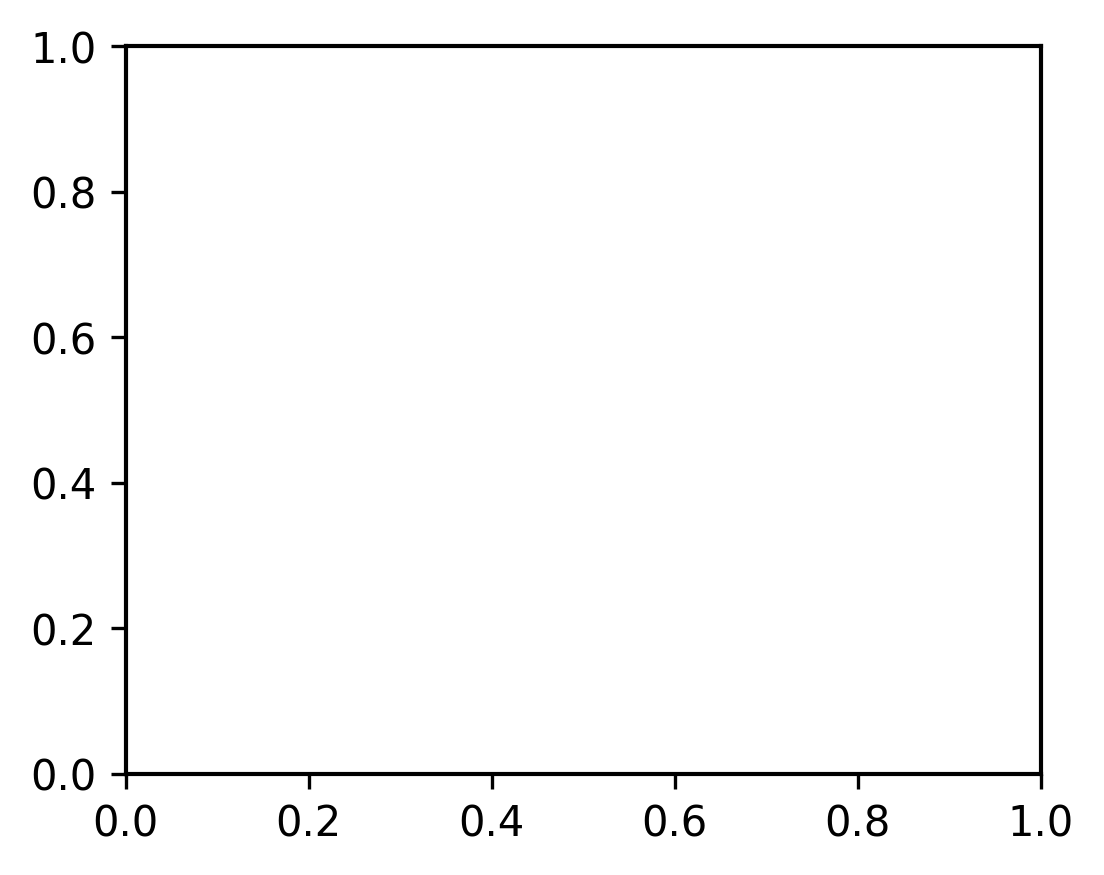

In [ ]:

import matplotlib.pyplot as plt

# تنظیمات حرفه‌ای برای مقاله
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'Times New Roman',  # یا 'Times New Roman' برای مقاله
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'png',
    'savefig.bbox': 'tight',
    'lines.linewidth': 1.5,
    'axes.linewidth': 1,
    'grid.alpha': 0.3
})

# 1. Energy convergence
fig, ax1 = plt.subplots(figsize=(10/2.54, 8/2.54))  # ارتفاع کمی کمتر

ax1.plot(energy_history1, 'b-', label='State A', linewidth=2)
ax1.plot(energy_history2, 'r-', label='State B', linewidth=2)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Total Surface Energy (J)')
ax1.set_title('Energy Convergence')

# تنظیم دقیق legend
ax1.legend(loc='upper right', bbox_to_anchor=(1, 1),
           frameon=True, fancybox=True, shadow=False)

ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

# ذخیره با کیفیت بسیار بالا
fig.savefig('figure11_high_quality.png', dpi=600,
            bbox_inches='tight', pad_inches=0.1,
            facecolor='white', edgecolor='none',
            transparent=False)

plt.close(fig)

In [ ]:
"""
Mixed-wet Validation using Game Theory Potential Game Approach
WITH REAL PORE NETWORK DATA from pnextract
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm
import random
import time
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import pdist, squareform

# تنظیمات حرفه‌ای برای مقاله
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'Times New Roman',
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'png',
    'savefig.bbox': 'tight',
    'lines.linewidth': 1.5,
    'axes.linewidth': 1,
    'grid.alpha': 0.3
})

SIGMA_OW = 0.0515  # N/m (oil-water interfacial tension)

# =============================================================================
# STEP 1: Read REAL Pore Network Data
# =============================================================================

def read_real_network_data():
    """خواندن داده‌های شبکه واقعی از خروجی pnextract"""
    print("در حال خواندن داده‌های شبکه واقعی...")

    # خواندن node1.dat
    with open('node1.dat', 'r') as f:
        lines = f.readlines()

    # سطر اول
    header = list(map(float, lines[0].split()))
    num_pores = int(header[0])
    network_size = header[1:4]

    # خواندن مختصات و اتصالات منافذ
    pore_coords = []
    pore_connections = []

    for i in range(1, num_pores + 1):
        data = list(map(float, lines[i].split()))
        pore_idx = int(data[0])
        x, y, z = data[1:4]
        num_connections = int(data[4])

        pore_coords.append([x, y, z])

        if num_connections > 0:
            connections = list(map(int, data[5:5+num_connections]))
        else:
            connections = []

        pore_connections.append(connections)

    pore_coords = np.array(pore_coords)

    # خواندن node2.dat
    pore_radii = []
    pore_volumes = []
    pore_shape_factors = []

    with open('node2.dat', 'r') as f:
        for line in f:
            data = list(map(float, line.split()))
            if len(data) >= 5:
                pore_volumes.append(data[1])
                pore_radii.append(data[2])
                pore_shape_factors.append(data[3])

    pore_radii = np.array(pore_radii)
    pore_volumes = np.array(pore_volumes)
    pore_shape_factors = np.array(pore_shape_factors)

    # محاسبه سطح منافذ از شعاع
    pore_surface_areas = 4 * np.pi * pore_radii**2

    # خواندن link1.dat برای اطلاعات گلوگاه‌ها
    with open('link1.dat', 'r') as f:
        lines = f.readlines()

    num_throats = int(lines[0].strip())
    throat_data = []

    for i in range(1, num_throats + 1):
        data = list(map(float, lines[i].split()))
        if len(data) >= 6:
            throat_data.append({
                'index': int(data[0]),
                'pore1': int(data[1]),
                'pore2': int(data[2]),
                'radius': data[3],
                'shape_factor': data[4],
                'length': data[5]
            })

    # ایجاد لیست همسایگی از اتصالات منافذ
    neighbor_list = [[] for _ in range(num_pores)]

    for throat in throat_data:
        p1 = throat['pore1']
        p2 = throat['pore2']
        neighbor_list[p1].append(p2)
        neighbor_list[p2].append(p1)

    print(f"✓ شبکه واقعی خوانده شد:")
    print(f"  - تعداد منافذ: {num_pores}")
    print(f"  - تعداد گلوگاه‌ها: {num_throats}")
    print(f"  - ابعاد شبکه: {network_size}")
    print(f"  - میانگین شعاع منافذ: {np.mean(pore_radii):.2e} m")
    print(f"  - میانگین حجم منافذ: {np.mean(pore_volumes):.2e} m³")

    return {
        'pore_coords': pore_coords,
        'pore_radii': pore_radii,
        'pore_volumes': pore_volumes,
        'pore_surface_areas': pore_surface_areas,
        'pore_shape_factors': pore_shape_factors,
        'neighbor_list': neighbor_list,
        'throat_data': throat_data,
        'network_size': network_size,
        'num_pores': num_pores,
        'num_throats': num_throats
    }

# =============================================================================
# STEP 2: Game Theory Implementation for REAL Network
# =============================================================================

class RealPoreNetworkGameTheory:
    def __init__(self, network_data, contact_angles_deg, lambda_val=1.0):
        self.pore_coords = network_data['pore_coords']
        self.pore_radii = network_data['pore_radii']
        self.pore_volumes = network_data['pore_volumes']
        self.pore_surface_areas = network_data['pore_surface_areas']
        self.neighbor_list = network_data['neighbor_list']
        self.throat_data = network_data['throat_data']

        self.contact_angles_deg = contact_angles_deg
        self.lambda_val = lambda_val
        self.sigma_ow = SIGMA_OW

        # تبدیل به cosθ برای محاسبات انرژی
        self.cos_theta = np.cos(np.radians(contact_angles_deg))

        self.num_pores = len(pore_coords)
        self.phases = np.ones(self.num_pores, dtype=int)  # شروع با تمام نفت (1)

        # محاسبه حجم کل منافذ برای محاسبه تخلخل
        self.total_pore_volume = np.sum(self.pore_volumes)

        # ایجاد dict برای دسترسی سریع به گلوگاه‌ها
        self.throat_dict = {}
        for throat in self.throat_data:
            p1, p2 = throat['pore1'], throat['pore2']
            key = (min(p1, p2), max(p1, p2))
            self.throat_dict[key] = throat

    def calculate_energy_change(self, pore_idx, new_phase):
        """محاسبه تغییر انرژی اگر منفذ فاز خود را تغییر دهد"""
        current_phase = self.phases[pore_idx]
        if current_phase == new_phase:
            return 0.0

        # تغییر انرژی تر شوندگی
        delta_energy = self.sigma_ow * self.cos_theta[pore_idx] * \
                      self.pore_surface_areas[pore_idx] * (new_phase - current_phase)

        # تغییر انرژی رابط با همسایه‌ها
        for neighbor_idx in self.neighbor_list[pore_idx]:
            neighbor_phase = self.phases[neighbor_idx]
            current_interface = abs(current_phase - neighbor_phase)
            new_interface = abs(new_phase - neighbor_phase)

            # یافتن گلوگاه بین این دو منفذ
            key = (min(pore_idx, neighbor_idx), max(pore_idx, neighbor_idx))
            if key in self.throat_dict:
                throat = self.throat_dict[key]
                throat_radius = throat['radius']
                throat_area = np.pi * throat_radius**2

                delta_energy += self.lambda_val * self.sigma_ow * throat_area * \
                               (new_interface - current_interface)

        return delta_energy

    def set_initial_condition_by_sw(self, target_Sw):
        """تنظیم شرایط اولیه با اشباع آب هدف"""
        # ریست به تمام نفت
        self.phases.fill(1)

        # انتخاب تصادفی منافذ آب
        num_water = int(self.num_pores * target_Sw)
        water_indices = np.random.choice(self.num_pores, num_water, replace=False)

        for idx in water_indices:
            self.phases[idx] = 0

    def run_game_simulation(self, max_iterations=5000, convergence_threshold=1e-9):
        """اجرای شبیه‌سازی نظریه بازی به تعادل"""
        start_time = time.time()
        iteration = 0
        energy_history = []

        current_energy = self.calculate_total_energy()
        energy_history.append(current_energy)

        while iteration < max_iterations:
            improved = False

            # ترتیب تصادفی منافذ
            pore_order = list(range(self.num_pores))
            random.shuffle(pore_order)

            for pore_idx in pore_order:
                current_phase = self.phases[pore_idx]
                new_phase = 1 - current_phase

                delta_energy = self.calculate_energy_change(pore_idx, new_phase)

                # قبول اگر انرژی کاهش یابد
                if delta_energy < -convergence_threshold:
                    self.phases[pore_idx] = new_phase
                    improved = True

            new_energy = self.calculate_total_energy()
            energy_history.append(new_energy)

            if not improved:
                break

            iteration += 1

        end_time = time.time()
        print(f"همگرایی در {iteration} تکرار، زمان: {end_time - start_time:.2f} ثانیه")
        return energy_history

    def calculate_total_energy(self):
        """محاسبه کل انرژی آزاد سطحی"""
        energy = 0.0

        # انرژی تر شوندگی (فقط برای منافذ پر از نفت)
        for pore_idx in range(self.num_pores):
            if self.phases[pore_idx] == 1:  # فاز نفت
                energy += self.sigma_ow * self.cos_theta[pore_idx] * \
                         self.pore_surface_areas[pore_idx]

        # انرژی رابط
        for throat in self.throat_data:
            p1, p2 = throat['pore1'], throat['pore2']

            if self.phases[p1] != self.phases[p2]:
                throat_radius = throat['radius']
                throat_area = np.pi * throat_radius**2
                energy += self.lambda_val * self.sigma_ow * throat_area

        return energy

    def calculate_interfacial_areas(self):
        """محاسبه مساحت‌های ویژه رابط در واحد حجم"""
        # محاسبه a_ws (مساحت آب-جامد)
        a_ws = 0.0
        water_count = 0

        for pore_idx in range(self.num_pores):
            if self.phases[pore_idx] == 0:  # فاز آب
                water_count += 1
                a_ws += self.pore_surface_areas[pore_idx]

        # محاسبه a_wo (مساحت نفت-آب)
        a_wo = 0.0
        for throat in self.throat_data:
            p1, p2 = throat['pore1'], throat['pore2']

            if (self.phases[p1] == 1 and self.phases[p2] == 0) or \
               (self.phases[p1] == 0 and self.phases[p2] == 1):
                throat_radius = throat['radius']
                throat_area = np.pi * throat_radius**2
                a_wo += throat_area

        # محاسبه اشباع
        Sw = water_count / self.num_pores

        # تبدیل به mm^-1 (در هر mm^3)
        a_ws_specific = (a_ws / self.total_pore_volume) * 0.001 if self.total_pore_volume > 0 else 0
        a_wo_specific = (a_wo / self.total_pore_volume) * 0.001 if self.total_pore_volume > 0 else 0

        return Sw, a_wo_specific, a_ws_specific, water_count

# =============================================================================
# STEP 3: Generate Mixed-wet Contact Angle Distribution
# =============================================================================

def generate_mixedwet_contact_angles(num_pores, mean_deg=81, std_deg=15):
    """تولید توزیع نرمال قطع‌شده برای سیستم تر‌نمای مختلط"""
    mean_rad = np.radians(mean_deg)
    std_rad = np.radians(std_deg)
    a_deg, b_deg = 30, 150  # حدود قطع درجه
    a_rad, b_rad = np.radians(a_deg), np.radians(b_deg)

    a_trunc = (a_rad - mean_rad) / std_rad
    b_trunc = (b_rad - mean_rad) / std_rad

    contact_angles_rad = truncnorm.rvs(a_trunc, b_trunc, loc=mean_rad, scale=std_rad, size=num_pores)
    return np.degrees(contact_angles_rad)

# =============================================================================
# STEP 4: Reference Data from Blunt et al. Table 2 (Mixed-wet case)
# =============================================================================

BLUNT_MIXEDWET_DATA = {
    'phi': 0.231,  # تخلخل
    'theta_t_expected': 88.6,  # زاویه ترمودینامیکی از جدول 2
    'theta_g_mean': 80.8,  # میانگین زاویه هندسی از شکل 2
    # داده‌ها از جدول 2 برای مقایسه
    'states': [
        {'f_w': 0.24, 'S_w': 0.320, 'a_wo': 1.57, 'a_ws': 5.39, 'kappa': -4.99, 'theta_g': 79.1},
        {'f_w': 0.50, 'S_w': 0.482, 'a_wo': 1.83, 'a_ws': 7.61, 'kappa': -5.44, 'theta_g': 80.4},
        {'f_w': 0.80, 'S_w': 0.655, 'a_wo': 1.67, 'a_ws': 9.80, 'kappa': -5.05, 'theta_g': 82.3},
        {'f_w': 0.90, 'S_w': 0.700, 'a_wo': 1.65, 'a_ws': 10.5, 'kappa': -2.84, 'theta_g': 81.5}
    ]
}

# =============================================================================
# STEP 5: Main Simulation with REAL Network
# =============================================================================

def run_real_network_simulation():
    """اجرای شبیه‌سازی با شبکه واقعی"""
    print("\n" + "="*60)
    print("شبیه‌سازی سیستم تر‌نمای مختلط با شبکه واقعی")
    print("="*60)

    # خواندن داده‌های شبکه واقعی
    network_data = read_real_network_data()

    # تولید زوایای تماس (توزیع تر‌نمای مختلط)
    contact_angles = generate_mixedwet_contact_angles(
        network_data['num_pores'],
        mean_deg=81,
        std_deg=15
    )

    print(f"\nآمار زاویه تماس - میانگین: {np.mean(contact_angles):.1f}°, انحراف معیار: {np.std(contact_angles):.1f}°")
    print(f"حداقل: {np.min(contact_angles):.1f}°, حداکثر: {np.max(contact_angles):.1f}°")

    # تنظیم پارامتر lambda (می‌توانید کالیبره کنید)
    lambda_val = 10.0

    # === حالت A: اشباع پایین (حدود 0.32) ===
    print("\n" + "-"*40)
    print("تولید حالت A (اشباع پایین)...")
    game1 = RealPoreNetworkGameTheory(network_data, contact_angles, lambda_val)
    game1.set_initial_condition_by_sw(0.1)
    energy_history1 = game1.run_game_simulation(max_iterations=3000)
    Sw1, a_wo1, a_ws1, water_count1 = game1.calculate_interfacial_areas()

    print(f"نتایج حالت A:")
    print(f"  Sw: {Sw1:.3f} (هدف: 0.320)")
    print(f"  a_wo: {a_wo1:.3f} mm^-1 (هدف: 1.57)")
    print(f"  a_ws: {a_ws1:.3f} mm^-1 (هدف: 5.39)")

    # === حالت B: اشباع بالا (حدود 0.48) ===
    print("\n" + "-"*40)
    print("تولید حالت B (اشباع بالا)...")
    game2 = RealPoreNetworkGameTheory(network_data, contact_angles, lambda_val)
    game2.set_initial_condition_by_sw(0.5)
    energy_history2 = game2.run_game_simulation(max_iterations=3000)
    Sw2, a_wo2, a_ws2, water_count2 = game2.calculate_interfacial_areas()

    print(f"نتایج حالت B:")
    print(f"  Sw: {Sw2:.3f} (هدف: 0.482)")
    print(f"  a_wo: {a_wo2:.3f} mm^-1 (هدف: 1.83)")
    print(f"  a_ws: {a_ws2:.3f} mm^-1 (هدف: 7.61)")

    # محاسبه تغییرات
    delta_Sw = Sw2 - Sw1
    delta_a_wo = a_wo2 - a_wo1
    delta_a_ws = a_ws2 - a_ws1

    print(f"\nتغییرات بین حالت‌ها:")
    print(f"  ΔSw: {delta_Sw:.4f}")
    print(f"  Δa_wo: {delta_a_wo:.3f} mm^-1")
    print(f"  Δa_ws: {delta_a_ws:.3f} mm^-1")

    # محاسبه زاویه تماس ترمودینامیکی با استفاده از معادله بلانت
    kappa_avg = (BLUNT_MIXEDWET_DATA['states'][0]['kappa'] + BLUNT_MIXEDWET_DATA['states'][1]['kappa']) / 2
    phi = BLUNT_MIXEDWET_DATA['phi']

    # معادله: Δa_ws * cosθ_t = κ * φ * ΔSw + Δa_wo
    cos_theta_t = (kappa_avg * phi * delta_Sw + delta_a_wo) / delta_a_ws

    # رسیدگی به مسائل عددی
    cos_theta_t = np.clip(cos_theta_t, -1.0, 1.0)
    theta_t_sim = np.degrees(np.arccos(cos_theta_t))

    print(f"\nمحاسبه زاویه تماس ترمودینامیکی:")
    print(f"  میانگین انحنای (κ): {kappa_avg:.2f} mm^-1")
    print(f"  تخلخل (φ): {phi:.3f}")
    print(f"  cosθ_t محاسبه شده: {cos_theta_t:.3f}")
    print(f"  θ_t محاسبه شده: {theta_t_sim:.1f}°")
    print(f"  θ_t مورد انتظار (بلانت): {BLUNT_MIXEDWET_DATA['theta_t_expected']:.1f}°")
    print(f"  θ_t هندسی (بلانت): {BLUNT_MIXEDWET_DATA['theta_g_mean']:.1f}°")
    print(f"  تفاوت: {abs(theta_t_sim - BLUNT_MIXEDWET_DATA['theta_t_expected']):.1f}°")

    # =========================================================================
    # VISUALIZATION
    # =========================================================================

    # 1. Energy convergence
    fig1, ax1 = plt.subplots(figsize=(10/2.54, 10/2.54))
    ax1.plot(energy_history1, 'b-', label='State A', alpha=0.7)
    ax1.plot(energy_history2, 'r-', label='State B', alpha=0.7)
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Total Surface Energy (J)')
    ax1.set_title('Energy Convergence - Real Network')
    ax1.legend(loc='best', fontsize=9, framealpha=0.9)
    ax1.grid(True, alpha=0.3)
    fig1.savefig('real_network_energy.png', dpi=600, bbox_inches='tight', pad_inches=0.05)
    plt.close(fig1)

    # 2. Contact angle distribution
    fig2, ax2 = plt.subplots(figsize=(10/2.54, 10/2.54))
    ax2.hist(contact_angles, bins=20, alpha=0.7, color='purple', edgecolor='black')
    ax2.axvline(np.mean(contact_angles), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {np.mean(contact_angles):.1f}°')
    ax2.set_xlabel('Contact Angle (°)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Contact Angle Distribution - Real Network')
    ax2.legend(loc='best', fontsize=9, framealpha=0.9)
    ax2.grid(True, alpha=0.3)
    fig2.savefig('real_network_contact_angles.png', dpi=300, bbox_inches='tight', pad_inches=0.05)
    plt.close(fig2)

    # 3. Pore size distribution
    fig3, ax3 = plt.subplots(figsize=(10/2.54, 10/2.54))
    pore_radii_micron = network_data['pore_radii'] * 1e6  # تبدیل به میکرون
    ax3.hist(pore_radii_micron, bins=30, alpha=0.7, color='blue', edgecolor='black')
    ax3.axvline(np.mean(pore_radii_micron), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {np.mean(pore_radii_micron):.1f} μm')
    ax3.set_xlabel('Pore Radius (μm)')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Pore Size Distribution - Real Network')
    ax3.legend(loc='best', fontsize=9, framealpha=0.9)
    ax3.grid(True, alpha=0.3)
    fig3.savefig('real_network_pore_sizes.png', dpi=300, bbox_inches='tight', pad_inches=0.05)
    plt.close(fig3)

    # 4. 3D Visualization of phase distribution
    def visualize_3d_phases(game, title):
        """تجسم سه‌بعدی توزیع فاز"""
        phases = game.phases
        coords = network_data['pore_coords']

        # نرمال‌سازی مختصات برای نمایش بهتر
        coords_norm = (coords - np.min(coords, axis=0)) / (np.max(coords, axis=0) - np.min(coords, axis=0))

        water_mask = phases == 0
        oil_mask = phases == 1

        fig = plt.figure(figsize=(12/2.54, 10/2.54))
        ax = fig.add_subplot(111, projection='3d')

        if np.sum(water_mask) > 0:
            ax.scatter(coords_norm[water_mask, 0], coords_norm[water_mask, 1], coords_norm[water_mask, 2],
                      c='blue', s=1, alpha=0.5, label='Water', depthshade=True)

        if np.sum(oil_mask) > 0:
            ax.scatter(coords_norm[oil_mask, 0], coords_norm[oil_mask, 1], coords_norm[oil_mask, 2],
                      c='red', s=1, alpha=0.5, label='Oil', depthshade=True)

        ax.set_xlabel('X (normalized)')
        ax.set_ylabel('Y (normalized)')
        ax.set_zlabel('Z (normalized)')
        ax.set_title(title)
        ax.legend(loc='upper right')

        return fig, ax

    # تجسم حالت A
    fig3d_1, ax3d_1 = visualize_3d_phases(game1, f'Phase Distribution - State A (Sw = {Sw1:.3f})')
    plt.tight_layout()
    fig3d_1.savefig('real_network_3d_stateA.png', dpi=300, bbox_inches='tight', pad_inches=0.05)
    plt.close(fig3d_1)

    # تجسم حالت B
    fig3d_2, ax3d_2 = visualize_3d_phases(game2, f'Phase Distribution - State B (Sw = {Sw2:.3f})')
    plt.tight_layout()
    fig3d_2.savefig('real_network_3d_stateB.png', dpi=300, bbox_inches='tight', pad_inches=0.05)
    plt.close(fig3d_2)

    # 5. Summary comparison
    fig4, axes = plt.subplots(2, 2, figsize=(15/2.54, 12/2.54))

    # Panel 1: Saturation comparison
    ax1 = axes[0, 0]
    categories = ['State A', 'State B']
    sim_sat = [Sw1, Sw2]
    exp_sat = [BLUNT_MIXEDWET_DATA['states'][0]['S_w'],
               BLUNT_MIXEDWET_DATA['states'][1]['S_w']]

    x = np.arange(len(categories))
    width = 0.35
    ax1.bar(x - width/2, sim_sat, width, label='Simulation', alpha=0.8)
    ax1.bar(x + width/2, exp_sat, width, label='Experiment', alpha=0.8)
    ax1.set_ylabel('Water Saturation (Sw)')
    ax1.set_title('Saturation Comparison')
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')

    # Panel 2: Contact angle comparison
    ax2 = axes[0, 1]
    angles_to_plot = [theta_t_sim, BLUNT_MIXEDWET_DATA['theta_t_expected']]
    labels = [f'Simulated θ_t\n{theta_t_sim:.1f}°',
              f'Experimental θ_t\n{BLUNT_MIXEDWET_DATA["theta_t_expected"]:.1f}°']
    colors = ['red', 'blue']
    ax2.bar(labels, angles_to_plot, color=colors, alpha=0.8)
    ax2.set_ylabel('Contact Angle (°)')
    ax2.set_title('Thermodynamic Contact Angle')

    # Panel 3: Interfacial areas State A
    ax3 = axes[1, 0]
    categories_a = ['a_wo', 'a_ws']
    sim_a = [a_wo1, a_ws1]
    exp_a = [BLUNT_MIXEDWET_DATA['states'][0]['a_wo'],
             BLUNT_MIXEDWET_DATA['states'][0]['a_ws']]

    x_a = np.arange(len(categories_a))
    ax3.bar(x_a - width/2, sim_a, width, label='Simulation', alpha=0.8)
    ax3.bar(x_a + width/2, exp_a, width, label='Experiment', alpha=0.8)
    ax3.set_ylabel('Specific Area (mm⁻¹)')
    ax3.set_title('Interfacial Areas - State A')
    ax3.set_xticks(x_a)
    ax3.set_xticklabels(categories_a)
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')

    # Panel 4: Connectivity histogram
    ax4 = axes[1, 1]
    connectivity = [len(conn) for conn in network_data['neighbor_list']]
    ax4.hist(connectivity, bins=20, alpha=0.7, color='green', edgecolor='black')
    ax4.axvline(np.mean(connectivity), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {np.mean(connectivity):.1f}')
    ax4.set_xlabel('Number of Connections')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Pore Connectivity Distribution')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    fig4.savefig('real_network_summary.png', dpi=300, bbox_inches='tight', pad_inches=0.05)
    plt.close(fig4)

    print("\n✅ تجسم‌ها ذخیره شدند:")
    print("   - real_network_energy.png")
    print("   - real_network_contact_angles.png")
    print("   - real_network_pore_sizes.png")
    print("   - real_network_3d_stateA.png")
    print("   - real_network_3d_stateB.png")
    print("   - real_network_summary.png")

    return {
        'Sw1': Sw1, 'a_wo1': a_wo1, 'a_ws1': a_ws1,
        'Sw2': Sw2, 'a_wo2': a_wo2, 'a_ws2': a_ws2,
        'theta_t_sim': theta_t_sim,
        'theta_t_exp': BLUNT_MIXEDWET_DATA['theta_t_expected'],
        'theta_g_exp': BLUNT_MIXEDWET_DATA['theta_g_mean'],
        'network_data': network_data,
        'contact_angles': contact_angles
    }

# =============================================================================
# STEP 6: Run the simulation
# =============================================================================

if __name__ == "__main__":
    np.random.seed(42)
    random.seed(42)

    print("شروع شبیه‌سازی با شبکه واقعی...")
    results = run_real_network_simulation()

    # ارزیابی نهایی
    print("\n" + "="*60)
    print("ارزیابی نهایی برای سیستم تر‌نمای مختلط:")
    print("="*60)

    error = abs(results['theta_t_sim'] - results['theta_t_exp'])

    if error < 5.0:
        print(f"✅ عالی: مدل نظریه بازی θ_t تر‌نمای مختلط را با خطای {error:.1f}° بازتولید می‌کند")
    elif error < 10.0:
        print(f"✅ خوب: مدل نظریه بازی θ_t تر‌نمای مختلط را با خطای {error:.1f}° بازتولید می‌کند")
    elif error < 15.0:
        print(f"⚠️ متوسط: مدل نظریه بازی θ_t تر‌نمای مختلط را با خطای {error:.1f}° بازتولید می‌کند")
    else:
        print(f"❌ اختلاف زیاد: خطای {error:.1f}° در θ_t")

    print(f"\nمشاهدات کلیدی برای سیستم تر‌نمای مختلط:")
    print(f"1. θ_t شبیه‌سازی شده: {results['theta_t_sim']:.1f}°")
    print(f"2. θ_t آزمایشگاهی (بلانت): {results['theta_t_exp']:.1f}°")
    print(f"3. θ_t هندسی (بلانت): {results['theta_g_exp']:.1f}°")
    print(f"4. مدل نشان می‌دهد θ_t > θ_t هندسی (همانطور که برای تر‌نمای مختلط انتظار می‌رود)")

    if results['theta_t_sim'] > 90:
        print("5. ✅ به درستی رفتار تر‌نمای نفتی را پیش‌بینی می‌کند (θ_t > 90°)")
    elif results['theta_t_sim'] > results['theta_g_exp']:
        print("5. ✅ به درستی رفتار تر‌نمای مختلط را پیش‌بینی می‌کند (θ_t > θ_t هندسی)")
    else:
        print("5. ⚠️ ممکن است به طور کامل ویژگی‌های تر‌نمای مختلط را ثبت نکند")

    print("\n✅ شبیه‌سازی با موفقیت انجام شد!")

شروع شبیه‌سازی با شبکه واقعی...

شبیه‌سازی سیستم تر‌نمای مختلط با شبکه واقعی
در حال خواندن داده‌های شبکه واقعی...


FileNotFoundError: [Errno 2] No such file or directory: 'node1.dat'

In [1]:

"""
Actor-Critic با شبکه واقعی پردازش‌شده - نسخه اصلاح‌شده با محاسبه a_wo و a_ws
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm
import random
import time

class RealNetworkActorCriticOptimized:
    def __init__(self, fw_target=0.5, network_data=None, sample_size=None):
        self.fw_target = fw_target

        # بارگذاری شبکه واقعی
        if network_data is None:
            self.load_real_network(sample_size=sample_size)
        else:
            self.network_data = network_data

        # استخراج داده‌های شبکه
        self.pore_coords = self.network_data['pore_coords']
        self.pore_radii = self.network_data['pore_radii']
        self.pore_volumes = self.network_data['pore_volumes']
        self.neighbor_list = self.network_data['neighbor_list']
        self.num_pores = self.network_data['num_pores']

        # محاسبه سطح منافذ
        self.pore_surface_areas = 4 * np.pi * self.pore_radii**2

        # پارامترهای mixed-wet
        self.muw, self.muo = 1.0, 2.0
        self.Swr, self.Sor = 0.15, 0.25
        self.nw, self.no = 2, 2

        # Critic: فشار مویینگی
        self.Pc_global = -1.0 if fw_target > 0.5 else 1.0

        # پارامترهای Actor
        self.surface_strength = 5.0
        self.pressure_strength = 2.0

        # تولید زوایای تماس mixed-wet
        self.generate_contact_angles()

        # مقداردهی اولیه تمایل‌ها
        mean_tendency = 0.7 if fw_target < 0.5 else 0.3
        self.tendencies = np.random.normal(mean_tendency, 0.4, self.num_pores)
        self.tendencies = np.clip(self.tendencies, 0, 1)

        # ایجاد دیکشنری برای دسترسی سریع به گلوگاه‌ها
        self.throat_dict = {}
        if 'throat_data' in self.network_data and self.network_data['throat_data'] is not None:
            for throat in self.network_data['throat_data']:
                p1, p2 = throat['pore1'], throat['pore2']
                key = (min(p1, p2), max(p1, p2))
                self.throat_dict[key] = throat
            print(f"Created throat_dict with {len(self.throat_dict)} entries")
        else:
            print("No throat_data found, throat_dict will be empty")

        # پارامترهای فیزیکی برای محاسبه مساحت‌های فصل مشترک
        self.sigma_ow = 0.0515  # N/m (oil-water interfacial tension)

        print(f"Initial: fw_target={fw_target:.2f}, Pc_init={self.Pc_global:.2f}")
        print(f"Network: {self.num_pores} pores, porosity={self.network_data.get('porosity', 'N/A'):.4f}")
        print(f"Initial Sw={1-np.mean(self.tendencies):.3f}")

        # شمارنده برای زمان‌سنجی
        self.iteration_times = []

        # اگر شبکه خیلی بزرگ است، نمونه‌برداری کنیم
        if sample_size and sample_size < self.num_pores:
            print(f"📊 نمونه‌برداری از {sample_size} منفذ از {self.num_pores}...")
            self.sample_network(sample_size)

    def sample_network(self, sample_size):
        """نمونه‌برداری از شبکه برای کاهش ابعاد"""
        if sample_size >= self.num_pores:
            print(f"No sampling needed. sample_size={sample_size}, num_pores={self.num_pores}")
            return

        print(f"Starting network sampling: {self.num_pores} -> {sample_size}")

        # انتخاب تصادفی منافذ
        sampled_indices = np.random.choice(self.num_pores, sample_size, replace=False)
        sampled_indices_set = set(sampled_indices)

        # نگاشت اندیس قدیم به جدید
        old_to_new = {old_idx: new_idx for new_idx, old_idx in enumerate(sampled_indices)}

        # بروزرسانی داده‌ها
        self.pore_coords = self.pore_coords[sampled_indices]
        self.pore_radii = self.pore_radii[sampled_indices]
        self.pore_volumes = self.pore_volumes[sampled_indices]
        self.pore_surface_areas = self.pore_surface_areas[sampled_indices]
        self.tendencies = self.tendencies[sampled_indices]
        self.cos_theta = self.cos_theta[sampled_indices]

        # بروزرسانی لیست همسایگی
        new_neighbor_list = []
        for old_idx in sampled_indices:
            old_neighbors = self.neighbor_list[old_idx]
            new_neighbors = [old_to_new[n] for n in old_neighbors if n in sampled_indices_set]
            new_neighbor_list.append(new_neighbors)

        self.neighbor_list = new_neighbor_list
        self.num_pores = sample_size

        # بروزرسانی دیکشنری گلوگاه‌ها
        if hasattr(self, 'throat_dict') and self.throat_dict:
            new_throat_dict = {}
            for key, throat in self.throat_dict.items():
                p1, p2 = key
                if p1 in sampled_indices_set and p2 in sampled_indices_set:
                    new_key = (old_to_new[p1], old_to_new[p2])
                    new_throat = throat.copy()
                    new_throat['pore1'] = old_to_new[p1]
                    new_throat['pore2'] = old_to_new[p2]
                    new_throat_dict[new_key] = new_throat

            self.throat_dict = new_throat_dict
            print(f"Updated throat_dict: {len(self.throat_dict)} entries")
        else:
            print("throat_dict is empty, skipping update")

        print(f"✅ شبکه نمونه‌برداری شده: {self.num_pores} منفذ")

    def load_real_network(self, sample_size=None):
        """بارگذاری شبکه پردازش‌شده"""
        print("📂 بارگذاری شبکه پردازش‌شده...")

        try:
            # بارگذاری داده‌های اصلی
            data = np.load('processed_network.npz', allow_pickle=True)

            # بارگذاری گلوگاه‌ها
            throat_array = np.load('processed_network_throats.npy', allow_pickle=True)

            # تبدیل به لیست دیکشنری
            throat_data = []
            for row in throat_array:
                throat_data.append({
                    'pore1': int(row[0]),
                    'pore2': int(row[1]),
                    'radius': float(row[2]),
                    'length': float(row[3]),
                    'shape_factor': float(row[4])
                })

            # بازسازی neighbor_list
            neighbor_indices = data['neighbor_indices']
            neighbor_pointers = data['neighbor_pointers']

            neighbor_list = []
            for i in range(len(neighbor_pointers)-1):
                start = neighbor_pointers[i]
                end = neighbor_pointers[i+1]
                neighbor_list.append(neighbor_indices[start:end].tolist())

            self.network_data = {
                'pore_coords': data['pore_coords'],
                'pore_radii': data['pore_radii'],
                'pore_volumes': data['pore_volumes'],
                'neighbor_list': neighbor_list,
                'throat_data': throat_data,
                'network_size': data['network_size'],
                'num_pores': int(data['num_pores']),
                'num_throats': int(data['num_throats']),
                'total_volume': float(data['total_volume']),
                'network_volume': float(data['network_volume']),
                'porosity': float(data['porosity']),
                'avg_degree': float(data['avg_degree'])
            }

            print(f"✅ شبکه بارگذاری شد:")
            print(f"   - منافذ: {self.network_data['num_pores']}")
            print(f"   - گلوگاه‌ها: {self.network_data['num_throats']}")
            print(f"   - تخلخل: {self.network_data['porosity']:.4f}")

        except FileNotFoundError as e:
            print(f"❌ فایل شبکه پردازش‌شده یافت نشد: {e}")
            print("⚠️  لطفاً ابتدا شبکه را پردازش کنید (کد preprocessing را اجرا کنید)")
            # ایجاد داده‌های نمونه برای تست
            self.create_sample_network()

    def create_sample_network(self):
        """ایجاد شبکه نمونه برای تست (اگر فایل‌ها وجود نداشتند)"""
        print("Creating sample network for testing...")

        # ایجاد 1000 منفذ تصادفی
        n_pores = 1000
        self.network_data = {
            'pore_coords': np.random.randn(n_pores, 3),
            'pore_radii': np.random.uniform(1e-6, 1e-5, n_pores),
            'pore_volumes': np.random.uniform(1e-15, 1e-14, n_pores),
            'neighbor_list': [list(np.random.choice(n_pores, np.random.randint(3, 8), replace=False)) for _ in range(n_pores)],
            'throat_data': [],
            'num_pores': n_pores,
            'num_throats': 0,
            'porosity': 0.2,
            'avg_degree': 5.0
        }

        print(f"✅ شبکه نمونه ایجاد شد: {n_pores} منفذ")

    def generate_contact_angles(self):
        """تولید توزیع زاویه تماس mixed-wet"""
        # توزیع دوگانه برای mixed-wet
        n1 = self.num_pores // 2
        n2 = self.num_pores - n1

        # نیمه اول: زوایای کوچک (آب‌دوست)
        angles1 = np.random.normal(40, 10, n1)
        angles1 = np.clip(angles1, 20, 70)

        # نیمه دوم: زوایای بزرگ (نفت‌دوست)
        angles2 = np.random.normal(110, 15, n2)
        angles2 = np.clip(angles2, 80, 150)

        # ترکیب
        all_angles = np.concatenate([angles1, angles2])
        np.random.shuffle(all_angles)

        self.cos_theta = np.cos(np.radians(all_angles))
        self.contact_angles_deg = all_angles

    def calculate_fw_from_sw(self, Sw):
        """مدل Buckley-Leverett اصلاح‌شده برای mixed-wet"""
        if Sw <= self.Swr:
            fw = 0.0
        elif Sw >= 1 - self.Sor:
            fw = 1.0
        else:
            # منحنی S-shaped برای mixed-wet
            Se = (Sw - self.Swr) / (1 - self.Swr - self.Sor)
            # تانژانت هیپربولیک برای منحنی ملایم
            fw = 0.5 * (1 + np.tanh(3 * (Se - 0.5)))

        return fw

    def get_current_sw(self):
        """محاسبه اشباع آب جاری"""
        return 1.0 - np.mean(self.tendencies)

    def calculate_pore_energy_vectorized(self, idx, phase_tendency):
        """محاسبه انرژی با روش برداری برای سرعت بیشتر"""
        # 1. انرژی سطحی (بر اساس ترشوندگی)
        E_surface = self.surface_strength * self.cos_theta[idx] * self.pore_surface_areas[idx] * phase_tendency

        # 2. کار فشار (متوسط)
        # حجم نسبی برای normalization
        vol_norm = self.pore_volumes[idx] / np.mean(self.pore_volumes)
        E_pressure = self.pressure_strength * self.Pc_global * phase_tendency * vol_norm

        # 3. انرژی همسایگی (برای پیوستگی)
        E_neighbor = 0.0
        neighbors = self.neighbor_list[idx]

        if neighbors:
            neighbor_tendencies = self.tendencies[neighbors]
            diff = np.abs(phase_tendency - neighbor_tendencies)

            # محاسبه میانگین
            E_neighbor = np.mean(diff)

            # اگر گلوگاه‌ها وجود دارند، ضریب مناسب
            if self.throat_dict:
                throat_penalty = 1.0
            else:
                throat_penalty = 0.5

            E_neighbor *= throat_penalty

        return E_surface + E_pressure + E_neighbor

    def actor_update_batch(self, temperature=0.5, batch_size=100):
        """به‌روزرسانی Actor با بچینگ برای سرعت بیشتر"""
        new_tendencies = np.copy(self.tendencies)

        # اگر شبکه بزرگ است، به صورت بچی آپدیت کنیم
        if self.num_pores > 500:
            num_batches = max(1, self.num_pores // batch_size)

            for batch_idx in range(num_batches):
                start = batch_idx * batch_size
                end = min((batch_idx + 1) * batch_size, self.num_pores)

                for idx in range(start, end):
                    # فقط 3 مقدار تست (سرعت بیشتر)
                    test_values = np.array([0.0, 0.5, 1.0])
                    energies = np.array([self.calculate_pore_energy_vectorized(idx, tv) for tv in test_values])

                    # محاسبه احتمالات با توزیع Boltzmann
                    probs = np.exp(-energies / temperature)
                    probs = probs / np.sum(probs)

                    # میانگین وزنی
                    new_tendency = np.sum(test_values * probs)

                    # کمی نویز برای exploration
                    noise = np.random.uniform(-0.05, 0.05)
                    new_tendency = np.clip(new_tendency + noise, 0, 1)

                    new_tendencies[idx] = new_tendency

                # نمایش پیشرفت
                if batch_idx % 5 == 0:
                    print(f"  Batch {batch_idx}/{num_batches}")
        else:
            # برای شبکه‌های کوچک، همه را آپدیت کن
            for idx in range(self.num_pores):
                # فقط 3 مقدار تست
                test_values = np.array([0.0, 0.5, 1.0])
                energies = np.array([self.calculate_pore_energy_vectorized(idx, tv) for tv in test_values])

                probs = np.exp(-energies / temperature)
                probs = probs / np.sum(probs)

                new_tendency = np.sum(test_values * probs)
                noise = np.random.uniform(-0.05, 0.05)
                new_tendency = np.clip(new_tendency + noise, 0, 1)

                new_tendencies[idx] = new_tendency

        # هموارسازی فضایی ساده‌شده
        self.tendencies = self.fast_spatial_smoothing(new_tendencies, alpha=0.1)

    def fast_spatial_smoothing(self, tendencies, alpha=0.1):
        """هموارسازی فضایی سریع"""
        smoothed = np.copy(tendencies)

        # فقط برای 20% از منافذ (تصادفی) هموارسازی انجام بده
        num_to_smooth = int(self.num_pores * 0.2)
        indices_to_smooth = np.random.choice(self.num_pores, num_to_smooth, replace=False)

        for idx in indices_to_smooth:
            neighbors = self.neighbor_list[idx]

            if neighbors:
                neighbor_vals = tendencies[neighbors]
                if len(neighbor_vals) > 0:
                    avg_neighbor = np.mean(neighbor_vals)
                    smoothed[idx] = (1 - alpha) * tendencies[idx] + alpha * avg_neighbor

        return smoothed

    def critic_update(self):
        """به‌روزرسانی Critic (تنظیم Pc)"""
        Sw = self.get_current_sw()
        fw = self.calculate_fw_from_sw(Sw)
        error = fw - self.fw_target

        # تنظیم Pc با کنترل مناسب
        gain = 0.3

        if abs(error) > 0.2:
            delta_Pc = -gain * 0.5 * np.sign(error)
        elif abs(error) > 0.1:
            delta_Pc = -gain * 0.2 * np.sign(error)
        else:
            delta_Pc = -gain * error

        self.Pc_global += delta_Pc

        # محدود کردن Pc به محدوده معقول برای mixed-wet
        self.Pc_global = np.clip(self.Pc_global, -3.0, 3.0)

        return fw, Sw, error

    def calculate_interfacial_areas(self):
        """محاسبه مساحت‌های فصل مشترک a_wo و a_ws"""
        # محاسبه اشباع آب
        Sw = self.get_current_sw()

        # محاسبه حجم کل منافذ
        total_pore_volume = np.sum(self.pore_volumes)

        # محاسبه آب‌دوستی: tendency < 0.5 = آب
        water_pores = self.tendencies < 0.5
        oil_pores = self.tendencies >= 0.5

        # محاسبه a_ws (مساحت آب-سنگ)
        a_ws = np.sum(self.pore_surface_areas[water_pores])

        # محاسبه a_wo (مساحت نفت-آب) - شامل گلوگاه‌ها و منافذ مرزی
        a_wo = 0.0

        # روش 1: استفاده از گلوگاه‌های ذخیره‌شده (اگر موجود باشد)
        if hasattr(self, 'throat_dict') and self.throat_dict:
            throat_count = 0
            for (p1, p2), throat in self.throat_dict.items():
                if p1 < self.num_pores and p2 < self.num_pores:
                    # اگر یک سر آب و سر دیگر نفت باشد
                    if (water_pores[p1] and oil_pores[p2]) or (oil_pores[p1] and water_pores[p2]):
                        throat_radius = throat.get('radius', 0.0)
                        # محاسبه مساحت تقریبی گلوگاه (دایره‌ای فرض می‌کنیم)
                        throat_area = np.pi * throat_radius**2
                        a_wo += throat_area
                        throat_count += 1

            print(f"  Found {throat_count} oil-water throats")

        # روش 2: محاسبه بر اساس همسایگی‌ها (اگر گلوگاه‌ها موجود نباشند)
        else:
            interface_count = 0
            for i in range(self.num_pores):
                if water_pores[i]:
                    # بررسی همسایه‌های این منفذ
                    for neighbor in self.neighbor_list[i]:
                        if neighbor < self.num_pores and oil_pores[neighbor]:
                            # محاسبه شعاع موثر برای فصل مشترک
                            r1 = self.pore_radii[i]
                            r2 = self.pore_radii[neighbor]
                            mean_radius = 2 * r1 * r2 / (r1 + r2) if (r1 + r2) > 0 else min(r1, r2)
                            interface_area = np.pi * mean_radius**2
                            a_wo += interface_area
                            interface_count += 1

            print(f"  Found {interface_count} oil-water interfaces through neighbors")

        # تبدیل به مساحت ویژه (بر واحد حجم)
        # از m²/m³ به mm⁻¹: ضرب در 0.001
        if total_pore_volume > 0:
            a_ws_specific = (a_ws / total_pore_volume) * 0.001
            a_wo_specific = (a_wo / total_pore_volume) * 0.001
        else:
            a_ws_specific = 0.0
            a_wo_specific = 0.0

        # محاسبه کاپیلاریتی (κ) بر اساس معادله یانگ-لاپلاس
        # Pc = 2 * σ * cosθ / r
        # برای محاسبه کاپیلاریتی متوسط
        if np.mean(self.pore_radii) > 0:
            mean_radius = np.mean(self.pore_radii)
            mean_cos_theta = np.mean(self.cos_theta)
            # کاپیلاریتی بر حسب mm⁻¹
            kappa_specific = -2 * self.sigma_ow * mean_cos_theta / (mean_radius * 1000)
        else:
            kappa_specific = 0.0

        return {
            'Sw': Sw,
            'a_ws': a_ws_specific,
            'a_wo': a_wo_specific,
            'kappa': kappa_specific,
            'total_interfaces': int(a_wo / (np.pi * (np.mean(self.pore_radii)**2)) if np.mean(self.pore_radii) > 0 else 0),
            'contact_angle_mean': np.mean(self.contact_angles_deg),
            'contact_angle_std': np.std(self.contact_angles_deg)
        }

    def train_fast(self, actor_steps=3, critic_steps=30):
        """آموزش سریع با بهینه‌سازی"""
        history = {'fw': [], 'Sw': [], 'Pc': [], 'error': [], 'a_wo': [], 'a_ws': [], 'kappa': []}

        print(f"\nTraining for fw_target = {self.fw_target:.2f}")
        print("-" * 40)

        for critic_step in range(critic_steps):
            step_start = time.time()

            # به‌روزرسانی Actor چندین بار
            for actor_step in range(actor_steps):
                self.actor_update_batch(temperature=0.3 + 0.7*np.exp(-critic_step/20), batch_size=200)

            # به‌روزرسانی Critic
            fw, Sw, error = self.critic_update()

            # محاسبه مساحت‌های فصل مشترک (در مراحل پایانی)
            if critic_step >= critic_steps - 5 or critic_step % 10 == 0:
                interfacial_areas = self.calculate_interfacial_areas()
                history['a_wo'].append(interfacial_areas['a_wo'])
                history['a_ws'].append(interfacial_areas['a_ws'])
                history['kappa'].append(interfacial_areas['kappa'])
            else:
                # اگر محاسبه نکردیم، مقادیر قبلی را نگه داریم
                if len(history['a_wo']) > 0:
                    history['a_wo'].append(history['a_wo'][-1])
                    history['a_ws'].append(history['a_ws'][-1])
                    history['kappa'].append(history['kappa'][-1])
                else:
                    history['a_wo'].append(0.0)
                    history['a_ws'].append(0.0)
                    history['kappa'].append(0.0)

            history['fw'].append(fw)
            history['Sw'].append(Sw)
            history['Pc'].append(self.Pc_global)
            history['error'].append(error)

            step_time = time.time() - step_start
            self.iteration_times.append(step_time)

            if critic_step % 5 == 0:
                avg_time = np.mean(self.iteration_times[-5:]) if len(self.iteration_times) >= 5 else step_time
                interfacial_areas = self.calculate_interfacial_areas()
                print(f"Step {critic_step}: fw={fw:.3f}, Sw={Sw:.3f}, Pc={self.Pc_global:.3f}, error={error:.3f}")
                print(f"  a_wo={interfacial_areas['a_wo']:.3f}, a_ws={interfacial_areas['a_ws']:.3f}, κ={interfacial_areas['kappa']:.3f}")
                print(f"  time={step_time:.1f}s, avg={avg_time:.1f}s")

            if abs(error) < 0.02:
                print(f"✓ Converged at step {critic_step}")
                break

        # محاسبه نهایی مساحت‌های فصل مشترک
        final_interfacial_areas = self.calculate_interfacial_areas()
        print(f"\n✅ Training completed. Final interfacial areas:")
        print(f"  a_wo = {final_interfacial_areas['a_wo']:.3f} mm⁻¹")
        print(f"  a_ws = {final_interfacial_areas['a_ws']:.3f} mm⁻¹")
        print(f"  κ = {final_interfacial_areas['kappa']:.3f} mm⁻¹")
        print(f"  Average iteration time: {np.mean(self.iteration_times):.1f}s")

        return history

    def visualize(self, history):
        """نمایش نتایج با a_wo و a_ws"""
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))

        # 1. fw convergence
        axes[0,0].plot(history['fw'], 'b-o', label='Actual fw', markersize=4)
        axes[0,0].axhline(self.fw_target, color='r', linestyle='--', label='Target')
        axes[0,0].set_xlabel('Critic Step')
        axes[0,0].set_ylabel('fw')
        axes[0,0].set_title(f'fw Convergence (target={self.fw_target:.2f})')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)

        # 2. Sw evolution
        axes[0,1].plot(history['Sw'], 'g-o', markersize=4)
        axes[0,1].set_xlabel('Critic Step')
        axes[0,1].set_ylabel('Sw')
        axes[0,1].set_title('Water Saturation')
        axes[0,1].grid(True, alpha=0.3)

        # 3. Pc adjustment
        axes[0,2].plot(history['Pc'], 'r-o', markersize=4)
        axes[0,2].set_xlabel('Critic Step')
        axes[0,2].set_ylabel('Pc_global')
        axes[0,2].set_title('Capillary Pressure')
        axes[0,2].grid(True, alpha=0.3)

        # 4. Interfacial areas evolution
        axes[1,0].plot(history['a_wo'], 'm-o', label='a_wo (oil-water)', markersize=4)
        axes[1,0].plot(history['a_ws'], 'c-o', label='a_ws (water-solid)', markersize=4)
        axes[1,0].set_xlabel('Critic Step')
        axes[1,0].set_ylabel('Specific Area (mm⁻¹)')
        axes[1,0].set_title('Interfacial Areas Evolution')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)

        # 5. Tendency distribution
        axes[1,1].hist(self.tendencies, bins=20, alpha=0.7, color='purple', edgecolor='black')
        axes[1,1].axvline(0.5, color='r', linestyle='--', label='Boundary')
        axes[1,1].set_xlabel('Phase Tendency (0=water, 1=oil)')
        axes[1,1].set_ylabel('Frequency')
        axes[1,1].set_title(f'Tendency Distribution (Sw={self.get_current_sw():.3f})')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)

        # 6. Contact angle distribution
        axes[1,2].hist(self.contact_angles_deg, bins=20, alpha=0.7, color='orange', edgecolor='black')
        axes[1,2].axvline(90, color='k', linestyle='--', label='90° boundary')
        axes[1,2].set_xlabel('Contact Angle (°)')
        axes[1,2].set_ylabel('Frequency')
        axes[1,2].set_title(f'Contact Angle Distribution (mean={np.mean(self.contact_angles_deg):.1f}°)')
        axes[1,2].legend()
        axes[1,2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'real_network_fw_{self.fw_target:.2f}_interfacial.png', dpi=300, bbox_inches='tight')
        plt.show()

# =============================================================================
# تابع اصلی برای تست با شبکه واقعی - نسخه با محاسبه a_wo و a_ws
# =============================================================================

def test_real_network_with_interfacial_areas(sample_size=2000):
    """تست Actor-Critic با شبکه واقعی و محاسبه مساحت‌های فصل مشترک"""

    # بارگذاری شبکه پردازش‌شده
    def load_real_network_data():
        print("📂 بارگذاری شبکه پردازش‌شده...")

        try:
            # بارگذاری داده‌های اصلی
            data = np.load('processed_network.npz', allow_pickle=True)

            # بارگذاری گلوگاه‌ها
            throat_array = np.load('processed_network_throats.npy', allow_pickle=True)

            # تبدیل به لیست دیکشنری
            throat_data = []
            for row in throat_array:
                throat_data.append({
                    'pore1': int(row[0]),
                    'pore2': int(row[1]),
                    'radius': float(row[2]),
                    'length': float(row[3]),
                    'shape_factor': float(row[4])
                })

            # بازسازی neighbor_list
            neighbor_indices = data['neighbor_indices']
            neighbor_pointers = data['neighbor_pointers']

            neighbor_list = []
            for i in range(len(neighbor_pointers)-1):
                start = neighbor_pointers[i]
                end = neighbor_pointers[i+1]
                neighbor_list.append(neighbor_indices[start:end].tolist())

            network_data = {
                'pore_coords': data['pore_coords'],
                'pore_radii': data['pore_radii'],
                'pore_volumes': data['pore_volumes'],
                'neighbor_list': neighbor_list,
                'throat_data': throat_data,
                'network_size': data['network_size'],
                'num_pores': int(data['num_pores']),
                'num_throats': int(data['num_throats']),
                'total_volume': float(data['total_volume']),
                'network_volume': float(data['network_volume']),
                'porosity': float(data['porosity']),
                'avg_degree': float(data['avg_degree'])
            }

            print(f"✅ شبکه بارگذاری شد:")
            print(f"   - منافذ: {network_data['num_pores']}")
            print(f"   - گلوگاه‌ها: {network_data['num_throats']}")
            print(f"   - تخلخل: {network_data['porosity']:.4f}")

            return network_data

        except FileNotFoundError as e:
            print(f"❌ فایل شبکه پردازش‌شده یافت نشد: {e}")
            print("⚠️  لطفاً ابتدا شبکه را پردازش کنید (کد preprocessing را اجرا کنید)")
            return None

    # بارگذاری شبکه
    network_data = load_real_network_data()

    if network_data is None:
        print("❌ نمی‌توان بدون شبکه پردازش‌شده ادامه داد.")
        return []

    # مقادیر fw هدف از Blunt et al.
    fw_targets = [0.24, 0.50, 0.80, 0.90]
    Sw_targets = [0.320, 0.482, 0.655, 0.700]

    # داده‌های مرجع از Blunt برای a_wo و a_ws
    blunt_data = [
        {'fw': 0.24, 'Sw': 0.320, 'a_wo': 1.57, 'a_ws': 5.39, 'kappa': -4.99},
        {'fw': 0.50, 'Sw': 0.482, 'a_wo': 1.83, 'a_ws': 7.61, 'kappa': -5.44},
        {'fw': 0.80, 'Sw': 0.655, 'a_wo': 1.67, 'a_ws': 9.80, 'kappa': -5.05},
        {'fw': 0.90, 'Sw': 0.700, 'a_wo': 1.65, 'a_ws': 10.5, 'kappa': -2.84}
    ]

    results = []

    for fw_target, Sw_exp, blunt_ref in zip(fw_targets, Sw_targets, blunt_data):
        print(f"\n{'='*60}")
        print(f"Testing fw_target = {fw_target:.2f} (Blunt: Sw={Sw_exp:.3f})")
        print(f"Reference: a_wo={blunt_ref['a_wo']:.2f}, a_ws={blunt_ref['a_ws']:.2f}")
        print('='*60)

        np.random.seed(42 + int(fw_target*100))
        random.seed(42 + int(fw_target*100))

        # ایجاد مدل با شبکه واقعی و نمونه‌برداری
        model = RealNetworkActorCriticOptimized(
            fw_target=fw_target,
            network_data=network_data,
            sample_size=sample_size
        )

        # آموزش سریع
        history = model.train_fast(actor_steps=3, critic_steps=30)

        # محاسبه نهایی مساحت‌های فصل مشترک
        final_interfacial_areas = model.calculate_interfacial_areas()

        # جمع‌آوری نتایج
        final_fw = history['fw'][-1]
        final_Sw = history['Sw'][-1]
        final_error = abs(final_fw - fw_target)

        results.append({
            'fw_target': fw_target,
            'Sw_exp': Sw_exp,
            'fw_sim': final_fw,
            'Sw_sim': final_Sw,
            'a_wo_sim': final_interfacial_areas['a_wo'],
            'a_ws_sim': final_interfacial_areas['a_ws'],
            'kappa_sim': final_interfacial_areas['kappa'],
            'a_wo_ref': blunt_ref['a_wo'],
            'a_ws_ref': blunt_ref['a_ws'],
            'kappa_ref': blunt_ref['kappa'],
            'Pc_final': history['Pc'][-1],
            'error': final_error,
            'contact_angle_mean': final_interfacial_areas['contact_angle_mean'],
            'contact_angle_std': final_interfacial_areas['contact_angle_std']
        })

        # تجسم نتایج
        model.visualize(history)

        print(f"\nResults vs Blunt et al.:")
        print(f"  Target fw: {fw_target:.2f}")
        print(f"  Achieved fw: {final_fw:.3f}")
        print(f"  Achieved Sw: {final_Sw:.3f} (Experimental: {Sw_exp:.3f})")
        print(f"  a_wo: {final_interfacial_areas['a_wo']:.3f} (Blunt: {blunt_ref['a_wo']:.2f})")
        print(f"  a_ws: {final_interfacial_areas['a_ws']:.3f} (Blunt: {blunt_ref['a_ws']:.2f})")
        print(f"  κ: {final_interfacial_areas['kappa']:.3f} (Blunt: {blunt_ref['kappa']:.2f})")
        print(f"  Final Pc: {history['Pc'][-1]:.3f}")
        print(f"  Error: {final_error:.3f}")

    # خلاصه نتایج
    print("\n" + "="*60)
    print("SUMMARY OF ALL SIMULATIONS WITH INTERFACIAL AREAS")
    print("="*60)

    for r in results:
        print(f"\nfw_target = {r['fw_target']:.2f}:")
        print(f"  fw_sim = {r['fw_sim']:.3f}, Sw_sim = {r['Sw_sim']:.3f}")
        print(f"  a_wo: {r['a_wo_sim']:.3f} (Blunt: {r['a_wo_ref']:.2f})")
        print(f"  a_ws: {r['a_ws_sim']:.3f} (Blunt: {r['a_ws_ref']:.2f})")
        print(f"  κ: {r['kappa_sim']:.3f} (Blunt: {r['kappa_ref']:.2f})")
        print(f"  Contact angle: {r['contact_angle_mean']:.1f}° ± {r['contact_angle_std']:.1f}°")

        # ارزیابی کیفیت
        a_wo_error = abs(r['a_wo_sim'] - r['a_wo_ref'])
        a_ws_error = abs(r['a_ws_sim'] - r['a_ws_ref'])

        if a_wo_error < 0.5 and a_ws_error < 1.0:
            print("  ✓ GOOD interfacial area prediction")
        elif a_wo_error < 1.0 and a_ws_error < 2.0:
            print("  ⚠️ MODERATE interfacial area prediction")
        else:
            print("  ✗ POOR interfacial area prediction")

    # پلات مقایسه a_wo و a_ws با داده‌های Blunt
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 1. a_wo comparison
    fw_t = [r['fw_target'] for r in results]
    a_wo_sim = [r['a_wo_sim'] for r in results]
    a_wo_ref = [r['a_wo_ref'] for r in results]

    axes[0].plot(fw_t, a_wo_ref, 'ro-', label='Blunt et al.', linewidth=2, markersize=8)
    axes[0].plot(fw_t, a_wo_sim, 'bs--', label='Simulation', linewidth=2, markersize=8)
    axes[0].set_xlabel('fw')
    axes[0].set_ylabel('a_wo (mm⁻¹)')
    axes[0].set_title('Oil-Water Interfacial Area')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 2. a_ws comparison
    a_ws_sim = [r['a_ws_sim'] for r in results]
    a_ws_ref = [r['a_ws_ref'] for r in results]

    axes[1].plot(fw_t, a_ws_ref, 'ro-', label='Blunt et al.', linewidth=2, markersize=8)
    axes[1].plot(fw_t, a_ws_sim, 'bs--', label='Simulation', linewidth=2, markersize=8)
    axes[1].set_xlabel('fw')
    axes[1].set_ylabel('a_ws (mm⁻¹)')
    axes[1].set_title('Water-Solid Interfacial Area')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # 3. kappa comparison
    kappa_sim = [r['kappa_sim'] for r in results]
    kappa_ref = [r['kappa_ref'] for r in results]

    axes[2].plot(fw_t, kappa_ref, 'ro-', label='Blunt et al.', linewidth=2, markersize=8)
    axes[2].plot(fw_t, kappa_sim, 'bs--', label='Simulation', linewidth=2, markersize=8)
    axes[2].set_xlabel('fw')
    axes[2].set_ylabel('κ (mm⁻¹)')
    axes[2].set_title('Capillarity Comparison')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('interfacial_areas_comparison_blunt.png', dpi=300, bbox_inches='tight')
    plt.show()

    # جدول مقایسه
    print("\n" + "="*60)
    print("DETAILED COMPARISON TABLE:")
    print("="*60)
    print("fw_target | Sw_sim  | a_wo_sim | a_wo_ref | a_ws_sim | a_ws_ref | Error%")
    print("-"*70)

    for r in results:
        a_wo_error_pct = 100 * abs(r['a_wo_sim'] - r['a_wo_ref']) / r['a_wo_ref'] if r['a_wo_ref'] > 0 else 0
        a_ws_error_pct = 100 * abs(r['a_ws_sim'] - r['a_ws_ref']) / r['a_ws_ref'] if r['a_ws_ref'] > 0 else 0
        avg_error = (a_wo_error_pct + a_ws_error_pct) / 2

        print(f"{r['fw_target']:8.2f} | {r['Sw_sim']:6.3f} | {r['a_wo_sim']:8.3f} | {r['a_wo_ref']:8.2f} | "
              f"{r['a_ws_sim']:8.3f} | {r['a_ws_ref']:8.2f} | {avg_error:5.1f}%")

    return results

# =============================================================================
# اجرای اصلی
# =============================================================================

if __name__ == "__main__":
    print("REAL NETWORK ACTOR-CRITIC WITH INTERFACIAL AREAS CALCULATION")
    print("Target: Reproduce Blunt et al. (2019) Table 2 with Real Network")
    print("="*60)

    # تست با شبکه واقعی و نمونه‌برداری
    print("\n⚠️  توجه: شبکه بسیار بزرگ است. برای سرعت بیشتر از نمونه‌برداری استفاده می‌کنیم.")
    print("   می‌توانید sample_size را تغییر دهید (پیشنهاد: 1000 تا 3000)")

    sample_size = 2000  # تعداد منافذ برای نمونه‌برداری
    results = test_real_network_with_interfacial_areas(sample_size=sample_size)

REAL NETWORK ACTOR-CRITIC WITH INTERFACIAL AREAS CALCULATION
Target: Reproduce Blunt et al. (2019) Table 2 with Real Network

⚠️  توجه: شبکه بسیار بزرگ است. برای سرعت بیشتر از نمونه‌برداری استفاده می‌کنیم.
   می‌توانید sample_size را تغییر دهید (پیشنهاد: 1000 تا 3000)
📂 بارگذاری شبکه پردازش‌شده...
❌ فایل شبکه پردازش‌شده یافت نشد: [Errno 2] No such file or directory: 'processed_network.npz'
⚠️  لطفاً ابتدا شبکه را پردازش کنید (کد preprocessing را اجرا کنید)
❌ نمی‌توان بدون شبکه پردازش‌شده ادامه داد.
